# Dataset description
## Earthquake

**Source**: Sistema Geológico Colombiano 

**Download**: [Download](https://sish.sgc.gov.co/visor/)

# Code
## Imports

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

## Load data

In [5]:
path = "./data/sismicidad_historica.csv"

df = pd.read_csv(path, encoding="utf-8", usecols=["Fecha", "Magnitud", "Magnitud Tipo", "Profundidad"])

## Clean data

In [6]:
df.loc[len(df)] = ["2026/08/10", 7.4, "MW", 96.0]

df["Fecha"] = pd.to_datetime(df["Fecha"])
df["Fecha"] = df["Fecha"].dt.year
df = df[(df["Fecha"] >= 1900) & (df["Magnitud"] >= 5) & ~(df["Magnitud Tipo"].eq("MS"))]
df.set_index("Fecha", inplace=True)

## Plot

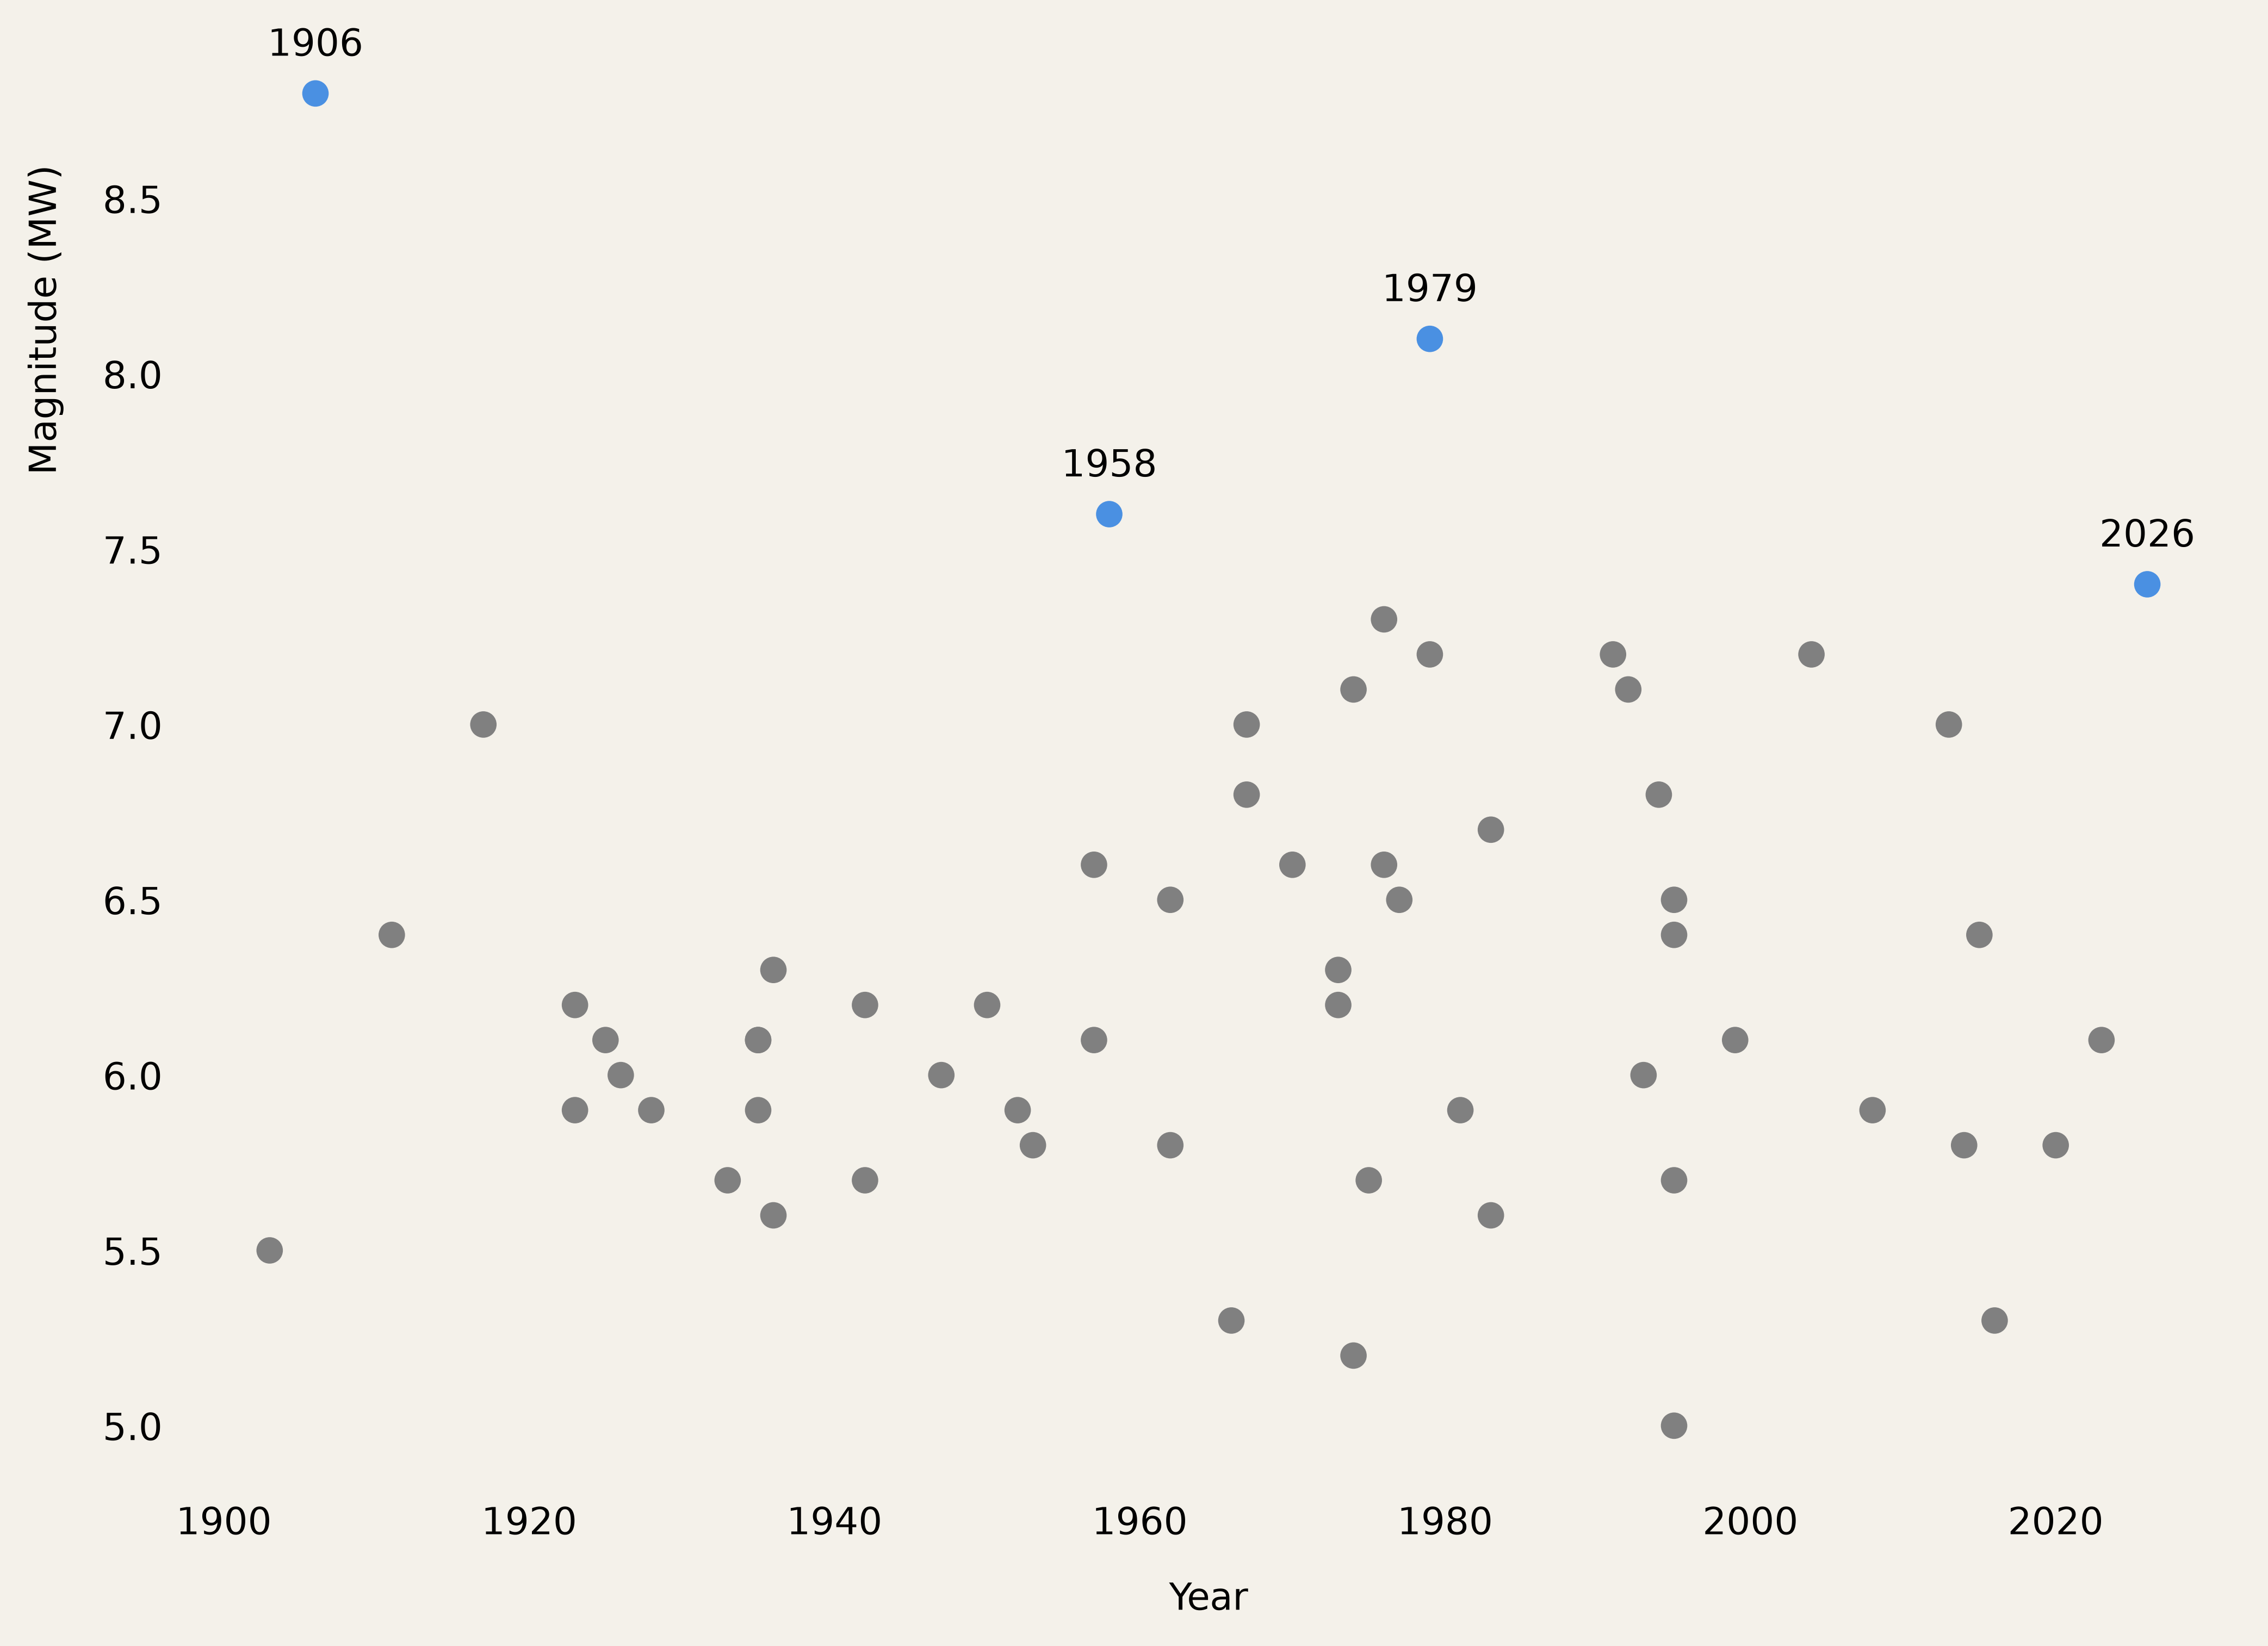

In [10]:
background = "#F4F1EA"
blue = "#4a90e2"
color = ["#4a90e2" if x >= 7.4 else "#808080" for x in df["Magnitud"]]

fig, ax = plt.subplots(figsize=(9.8, 7.0), dpi=500)
fig.patch.set_facecolor(background)
ax.patch.set_facecolor(background)

plt.scatter(df.index, df["Magnitud"], color=color)
for idx, row in df.iterrows():
    if row["Magnitud"] >= 7.4:
        plt.annotate(str(idx), (idx, row["Magnitud"]), 
                     textcoords="offset points", xytext=(0,10), ha="center")

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

plt.ylabel("Magnitude (MW)", labelpad=10, fontsize=10, y=0.8)
plt.xlabel("Year", labelpad=10, fontsize=10)

#plt.show()
plt.savefig('/home/riosandres/Pictures/Screenshots/a.svg', bbox_inches='tight', dpi=500, pad_inches=0)

## Extra information

In [12]:
deep = df[df["Magnitud"] >= 7.4]
deep.loc[:, ["Magnitud", "Profundidad"]]

,Magnitud,Profundidad
Fecha,,
1906,8.8,20.0
1958,7.6,27.5
1979,8.1,23.6
2026,7.4,96.0
